[Keras Functional API](https://machinelearningmastery.com/keras-functional-api-deep-learning/)

In [1]:
import torch
from torch.nn import Linear

# Dummy Data
X = torch.randn(size=[100, 20])
X_child = torch.randn(size=[100, 10])
y = torch.randn(size=[100, 1])

In [2]:
class FunctionalModel(torch.nn.Module):
    def __init__(self, parent_input_size: int=20, child_2_input_size: int=10):
        super().__init__()

        # Hyperparameters
        self.parent_linear_1_neurons = parent_input_size # 20
        self.parent_linear_2_neurons = parent_input_size // 2 # 10

        self.child_1_linear_neuron = 1

        self.child_2_linear_1_neuron = self.parent_linear_2_neurons + child_2_input_size
        self.child_2_linear_2_neuron = self.child_2_linear_1_neuron // 2
        self.child_2_linear_3_neuron = 1

        # Parent connection
        self.parent_linear_1 = Linear(in_features=parent_input_size, out_features=self.parent_linear_1_neurons)
        self.parent_linear_2 = Linear(in_features=self.parent_linear_1_neurons, out_features=self.parent_linear_2_neurons)

        # First Child connection
        self.child_1_linear = Linear(in_features=self.parent_linear_2_neurons, out_features=self.child_1_linear_neuron)

        # Second Child connection
        self.child_2_linear_1 = Linear(in_features=child_2_input_size + self.parent_linear_2_neurons, out_features=self.child_2_linear_1_neuron)
        self.child_2_linear_2 = Linear(in_features=self.child_2_linear_1_neuron, out_features=self.child_2_linear_2_neuron)
        self.child_2_linear_3 = Linear(in_features=self.child_2_linear_2_neuron + child_2_input_size + self.parent_linear_2_neurons, out_features=1)

    def forward(self, X_train_parent: torch.Tensor, X_train_child_2: torch.Tensor) -> torch.Tensor:
        # Parent result
        parent_res = self.parent_linear_1(X_train_parent)
        parent_res = self.parent_linear_2(parent_res) # [100, 10]
        
        # First Child result
        child_1_res = self.child_1_linear(parent_res) # [100, 1]

        # Second Child result
        concat_input = torch.concat(tensors=(parent_res, X_train_child_2), dim=1) # torch.Size([100, 20])
        child_2_res = self.child_2_linear_1(concat_input) # [100, 20]
        child_2_res = self.child_2_linear_2(child_2_res) # [100, 10]

        residual_input = torch.concat(tensors=(child_2_res, concat_input), dim=1)
        # print(residual_input.shape)
        child_2_res = self.child_2_linear_3(residual_input)

        return child_1_res, child_2_res

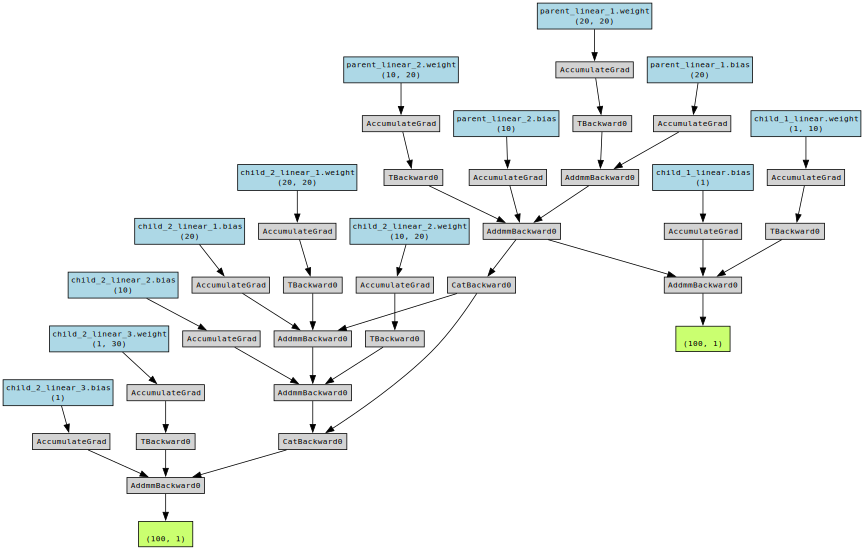

In [3]:
from torchviz import make_dot
model = FunctionalModel(20, 10)

network_1_res, network_2_res = model(X, X_child)
make_dot((network_1_res, network_2_res), params=dict(model.named_parameters()))